In [19]:
#imports
import pandas as pd
from generate_schedule import generate_schedule
from sim_season import simulate_season
from random_fpi import make_random_fpi
from playoffs import playoff_field
from collections import Counter
from real_nfl_schedule import build_real_season_dfs,real_schedule_df
import matplotlib.pyplot as plt
from simulate_playoffs import simulate_playoffs
import nflreadpy as nfl
import numpy as np
from scipy.stats import linregress

In [28]:
dfs = {}
for year in range(2015, 2025):
    dfs[year] = pd.read_csv(f"FPI_Years/FPI_{year}.csv")
    
team_to_abbr = {"Arizona Cardinals":"ARI",
    "Atlanta Falcons":"ATL",
    "Baltimore Ravens":"BAL",
    "Buffalo Bills":"BUF",
    "Carolina Panthers":"CAR",
    "Chicago Bears":"CHI",
    "Cincinnati Bengals":"CIN",
    "Cleveland Browns":"CLE",
    "Dallas Cowboys":"DAL",
    "Denver Broncos":"DEN",
    "Detroit Lions":"DET",
    "Green Bay Packers":"GB",
    "Houston Texans":"HOU",
    "Indianapolis Colts":"IND",
    "Jacksonville Jaguars":"JAX",
    "Kansas City Chiefs":"KC",
    "Las Vegas Raiders":"LV",
    "Los Angeles Chargers":"LAC",
    "Los Angeles Rams":"LA",
    "Miami Dolphins":"MIA",
    "Minnesota Vikings":"MIN",
    "New England Patriots":"NE",
    "New Orleans Saints":"NO",
    "New York Giants":"NYG",
    "New York Jets":"NYJ",
    "Philadelphia Eagles":"PHI",
    "Pittsburgh Steelers":"PIT",
    "San Francisco 49ers":"SF",
    "Seattle Seahawks":"SEA",
    "Tampa Bay Buccaneers":"TB",
    "Tennessee Titans":"TEN",
    "Washington Commanders":"WAS"
    }

corrected_teams = {"Oakland Raiders": "Las Vegas Raiders",
                   "St. Louis Rams": "Los Angeles Rams",
                   "San Diego Chargers": "Los Angeles Chargers"}

In [29]:
# Better tiebreaking procedures
# 1000 sims on the same FPI/Schedule seed
n = 100

df = pd.read_csv("FPI-1-11-26.csv")
df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=15)
schedule_df = generate_schedule(df_seeded, seed=1)

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed, tm_cap = 100)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "total_margin") 

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))


print(tb_counts)
print(fpi_counts)
#print(field_count)

field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("playoff_percentage").to_frame())

field_prob_df["Playoff_Percentage"] = field_prob_df["playoff_percentage"]/n
field_prob_df = field_prob_df.merge(df_seeded[["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")

print(field_prob_df)

Counter({'total_margin': 699})
Counter({'higher FPI won': 450, 'lower FPI won': 249})
                      playoff_percentage  Playoff_Percentage  FPI
Team                                                             
Jacksonville Jaguars                  99                0.99  6.3
Dallas Cowboys                        96                0.96  5.0
New York Giants                       91                0.91  4.2
Miami Dolphins                        84                0.84  2.2
Baltimore Ravens                      83                0.83  2.4
Carolina Panthers                     82                0.82  4.3
Denver Broncos                        78                0.78  2.2
Houston Texans                        70                0.70  3.0
Tampa Bay Buccaneers                  67                0.67  1.9
Atlanta Falcons                       62                0.62  2.1
Cincinatti Bengals                    60                0.60  0.6
Pittsburgh Steelers                   57                

In [31]:
# Better tiebreaking procedures
# Compare multiple tm_cap values on the same FPI / Schedule / sim seeds
n = 100

tm_caps = [50, 40, 30, 25, 20, 17, 14, 10, 7, 5]

df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=12)
schedule_df = generate_schedule(df_seeded, seed=1)

cap_results = []

for cap in tm_caps:
    tb_counts = Counter()
    fpi_counts = Counter()
    field_count = Counter()

    for sim_seed in range(1, n + 1):
        results_df, standings_df = simulate_season(
            df_seeded, schedule_df, seed=sim_seed, tm_cap=cap
        )

        field, tiebreakers, fpi_winners = playoff_field(
            standings_df, results_df, mode="capped_margin"
        )

        tb_counts.update(Counter(tiebreakers))
        fpi_counts.update(Counter(fpi_winners))
        field_count.update(Counter(field["Team"]))

    print(f"tm_cap = {cap}")
    print(tb_counts)
    print(fpi_counts)
    print()

    total_fpi_tiebreaks = sum(fpi_counts.values())
    higher_fpi_wins = fpi_counts["higher FPI won"]
    higher_fpi_win_pct = higher_fpi_wins / total_fpi_tiebreaks if total_fpi_tiebreaks > 0 else 0

    cap_results.append({
        "tm_cap": cap,
        "higher_FPI_won": higher_fpi_wins,
        "total_FPI_tiebreaks": total_fpi_tiebreaks,
        "higher_FPI_win_pct": higher_fpi_win_pct
    })

cap_results_df = pd.DataFrame(cap_results)
print(cap_results_df)

tm_cap = 50
Counter({'capped_margin': 699})
Counter({'higher FPI won': 450, 'lower FPI won': 249})

tm_cap = 40
Counter({'capped_margin': 699})
Counter({'higher FPI won': 450, 'lower FPI won': 249})

tm_cap = 30
Counter({'capped_margin': 699})
Counter({'higher FPI won': 450, 'lower FPI won': 249})

tm_cap = 25
Counter({'capped_margin': 699})
Counter({'higher FPI won': 443, 'lower FPI won': 256})

tm_cap = 20
Counter({'capped_margin': 699})
Counter({'higher FPI won': 437, 'lower FPI won': 262})

tm_cap = 17
Counter({'capped_margin': 699})
Counter({'higher FPI won': 432, 'lower FPI won': 267})

tm_cap = 14
Counter({'capped_margin': 699})
Counter({'higher FPI won': 433, 'lower FPI won': 266})

tm_cap = 10
Counter({'capped_margin': 699})
Counter({'higher FPI won': 435, 'lower FPI won': 264})

tm_cap = 7
Counter({'capped_margin': 699})
Counter({'higher FPI won': 427, 'lower FPI won': 272})

tm_cap = 5
Counter({'capped_margin': 699})
Counter({'higher FPI won': 427, 'lower FPI won': 272})

  

In [38]:
# Better tiebreaking procedures
# Compare multiple tm_cap values on the same FPI / Schedule / sim seeds
n = 100

tm_caps = [100,35,30,25,20,19]

df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=12)
schedule_df = generate_schedule(df_seeded, seed=1)

cap_results = []

for cap in tm_caps:
    tb_counts = Counter()
    fpi_counts = Counter()
    field_count = Counter()

    for sim_seed in range(1, n + 1):
        results_df, standings_df = simulate_season(
            df_seeded, schedule_df, seed=sim_seed, tm_cap=cap
        )

        field, tiebreakers, fpi_winners = playoff_field(
            standings_df, results_df, mode="capped_margin"
        )

        tb_counts.update(Counter(tiebreakers))
        fpi_counts.update(Counter(fpi_winners))
        field_count.update(Counter(field["Team"]))

    print(f"tm_cap = {cap}")
    print(tb_counts)
    print(fpi_counts)
    print()

    total_fpi_tiebreaks = sum(fpi_counts.values())
    higher_fpi_wins = fpi_counts["higher FPI won"]
    higher_fpi_win_pct = higher_fpi_wins / total_fpi_tiebreaks if total_fpi_tiebreaks > 0 else 0

    cap_results.append({
        "tm_cap": cap,
        "higher_FPI_won": higher_fpi_wins,
        "total_FPI_tiebreaks": total_fpi_tiebreaks,
        "higher_FPI_win_pct": higher_fpi_win_pct
    })

cap_results_df = pd.DataFrame(cap_results)
print(cap_results_df)

tm_cap = 100
Counter({'capped_margin': 709})
Counter({'higher FPI won': 461, 'lower FPI won': 248})

tm_cap = 35
Counter({'capped_margin': 709})
Counter({'higher FPI won': 462, 'lower FPI won': 247})

tm_cap = 30
Counter({'capped_margin': 709})
Counter({'higher FPI won': 463, 'lower FPI won': 246})

tm_cap = 25
Counter({'capped_margin': 709})
Counter({'higher FPI won': 462, 'lower FPI won': 247})

tm_cap = 20
Counter({'capped_margin': 709})
Counter({'higher FPI won': 461, 'lower FPI won': 248})

tm_cap = 19
Counter({'capped_margin': 709})
Counter({'higher FPI won': 458, 'lower FPI won': 251})

   tm_cap  higher_FPI_won  total_FPI_tiebreaks  higher_FPI_win_pct
0     100             461                  709            0.650212
1      35             462                  709            0.651622
2      30             463                  709            0.653032
3      25             462                  709            0.651622
4      20             461                  709            0.6502

In [47]:
season_lengths = [12, 16, 17, 34, 50, 100, 250, 500, 1000, 2500]
n_sims = 250

results = []

df = pd.read_csv("FPI-1-11-26.csv")

for season_length in season_lengths:
    
    fpi_win_corrs = []
    one_seed_fpi_ranks = []
    best_team_one_seed_count = 0
    best_team_sb_count = 0
    
    for sim_seed in range(1, n_sims + 1):
        
        df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
        schedule_df = generate_schedule(df_seeded, seed=sim_seed, season_length=season_length)
        results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
        field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)
        playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, seed=sim_seed)
        
        standings_temp = standings_df.copy()
        standings_temp["FPI_Rank"] = standings_temp["FPI"].rank(method="first", ascending=False)
        
        fpi_win_corrs.append(standings_temp["FPI"].corr(standings_temp["Wins"]))
        
        one_seed_rows = field[field["Seed"] == 1].merge(standings_temp[["Team", "FPI_Rank"]],on="Team",how="left")
        one_seed_fpi_ranks.extend(one_seed_rows["FPI_Rank"].tolist())
        
        best_fpi_team = standings_temp.sort_values("FPI", ascending=False)["Team"].iloc[0]
        
        if best_fpi_team in field[field["Seed"] == 1]["Team"].values:
            best_team_one_seed_count += 1
            
        if sb_winner == best_fpi_team:
            best_team_sb_count += 1
    
    results.append({"Season_Length": season_length,
        "Avg_FPI_Wins_Corr": np.mean(fpi_win_corrs), "Avg_1_Seed_FPI_Rank": np.mean(one_seed_fpi_ranks),
        "Best_FPI_Team_1_Seed_Prob": best_team_one_seed_count / n_sims, "Best_FPI_Team_SB_Prob": best_team_sb_count / n_sims})
    print("Done with", season_length)

results_df_summary = pd.DataFrame(results)
print(results_df_summary)

Coin flip! _________-----------_____________------------_______________-------- ['Minnesota Vikings', 'Dallas Cowboys']
Coin flip! _________-----------_____________------------_______________-------- ['Minnesota Vikings', 'Dallas Cowboys']
Coin flip! _________-----------_____________------------_______________-------- ['Philadelphia Eagles', 'Green Bay Packers']
Coin flip! _________-----------_____________------------_______________-------- ['Philadelphia Eagles', 'Washington Commanders']
Coin flip! _________-----------_____________------------_______________-------- ['Miami Dolphins', 'Houston Texans']
Done with 12
Done with 16
Done with 17
Done with 34
Done with 50
Done with 100
Coin flip! _________-----------_____________------------_______________-------- ['Arizona Cardinals', 'Dallas Cowboys']
Done with 250
Coin flip! _________-----------_____________------------_______________-------- ['Pittsburgh Steelers', 'Jacksonville Jaguars']
Done with 500
Done with 1000
Done with 2500
   S

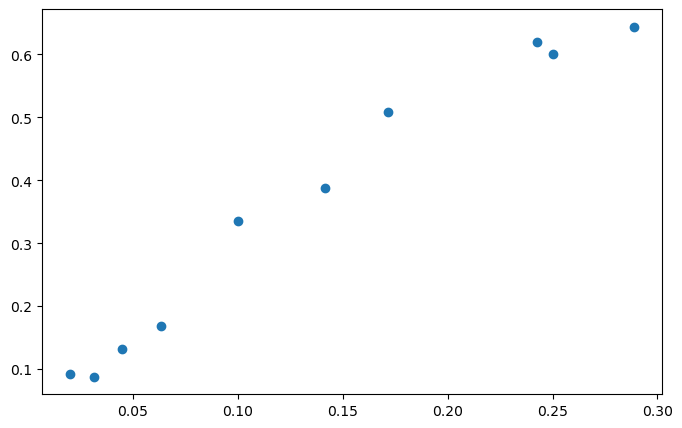

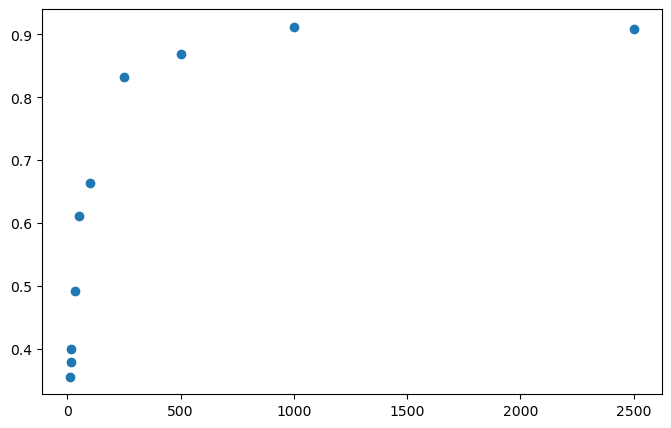

In [57]:
results_df_summary["Error"] = 1 - results_df_summary["Best_FPI_Team_1_Seed_Prob"]
results_df_summary["Inv_Sqrt_n"] = 1 / np.sqrt(results_df_summary["Season_Length"])

plt.figure(figsize=(8, 5))
plt.scatter(results_df_summary["Inv_Sqrt_n"], results_df_summary["Error"])
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(results_df_summary["Season_Length"],results_df_summary["Best_FPI_Team_1_Seed_Prob"])
